# House Prices — MLP Experiments
Five configurations E0–E4 are defined in `configs/baseline.yaml`. The notebook runs the shared `src.train` experiment function if the comparison is missing; existing verified results are presented directly.

In [1]:
from pathlib import Path
import sys
root = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Image
from src.train import run_all_experiments
table_path = root / 'outputs' / 'metrics' / 'experiments.csv'
expected = {'E0', 'E1', 'E2', 'E3', 'E4'}
if not table_path.exists() or set(pd.read_csv(table_path).experiment_name) != expected:
    run_all_experiments()
table = pd.read_csv(table_path)
assert set(table.experiment_name) == {'E0', 'E1', 'E2', 'E3', 'E4'}
display(table.sort_values('experiment_name'))
winner = table.sort_values(['best_val_rmse', 'experiment_name']).iloc[0]
print('Selected by validation RMSE:', winner.experiment_name, winner.best_val_rmse, 'at epoch', winner.best_epoch)

,experiment_name,architecture,dropout,learning_rate,weight_decay,best_epoch,best_val_rmse
0,E0,64-32,0.0,0.0010,0.0000,3,0.133316
1,E1,128-64-32,"[0.15, 0.1]",0.0010,0.0001,10,0.141518
2,E2,256-128-64,"[0.2, 0.15]",0.0010,0.0001,4,0.136446
3,E3,128-64-32,"[0.15, 0.1]",0.0005,0.0001,11,0.142573
4,E4,128-64-32,"[0.25, 0.15]",0.0010,0.0010,24,0.138196


Selected by validation RMSE: E0 0.1333156893597373 at epoch 3


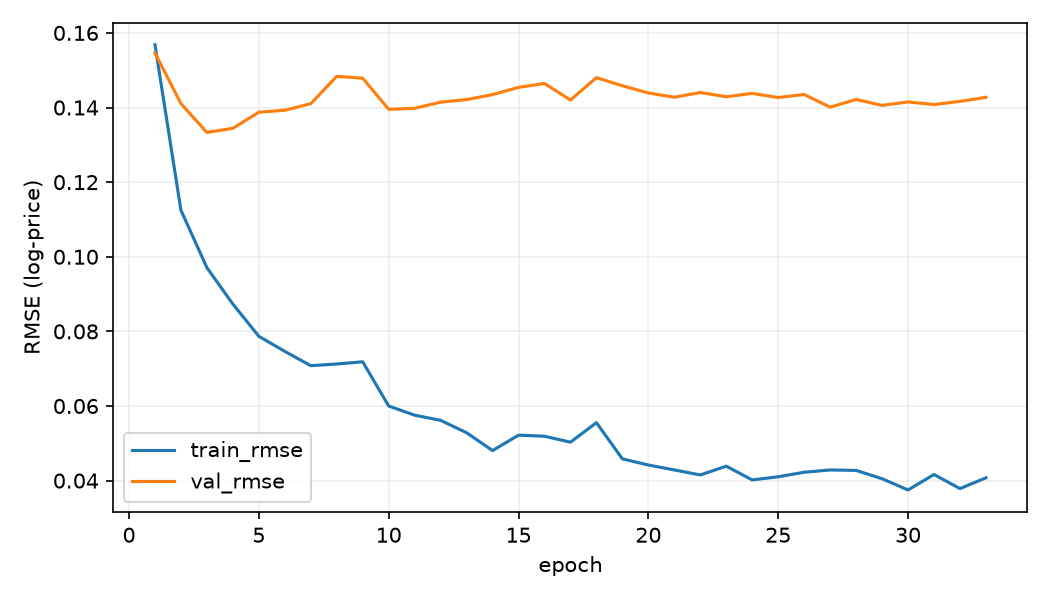

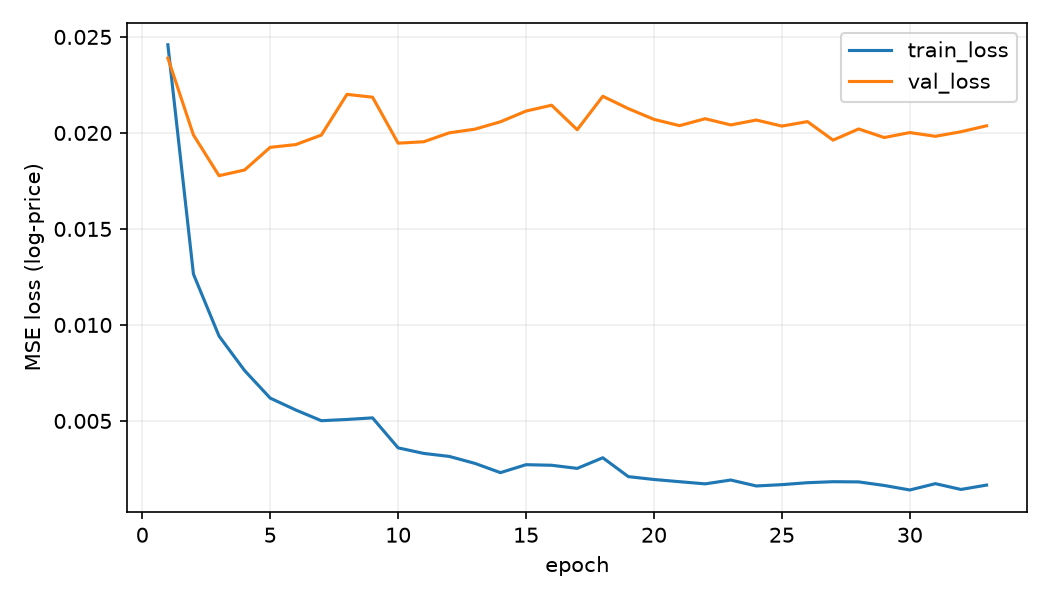

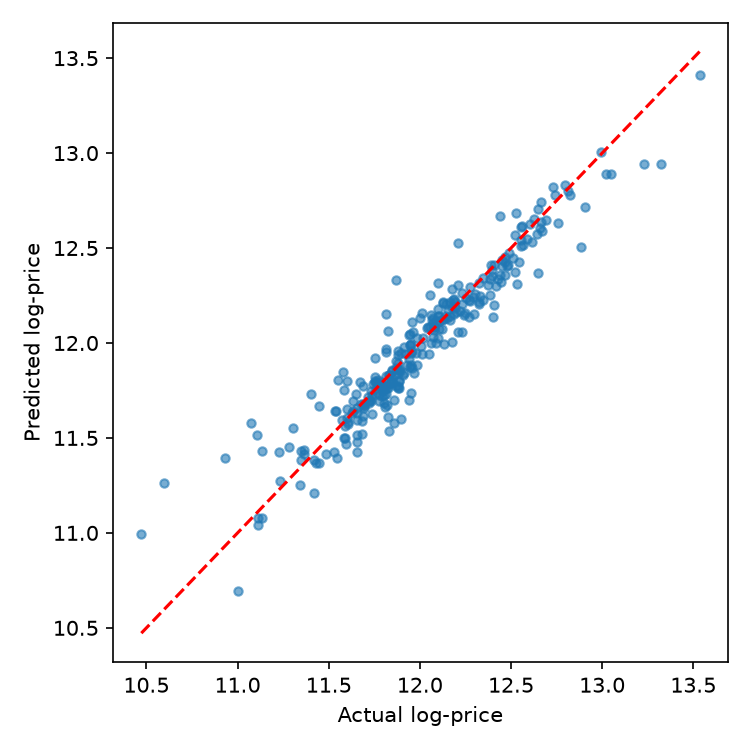

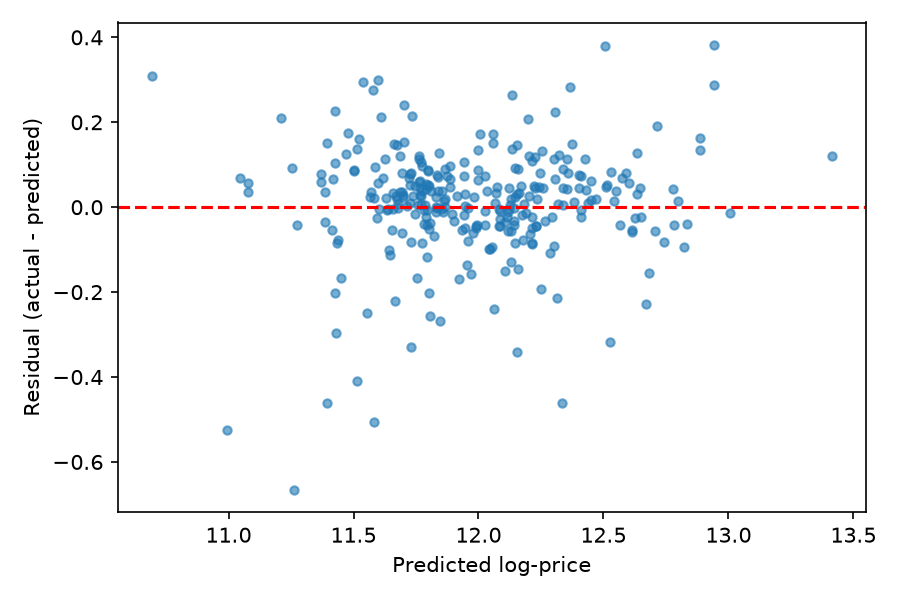

In [2]:
for suffix in ['rmse', 'loss', 'actual_predicted', 'residuals']:
    display(Image(filename=str(root / 'outputs' / 'figures' / f'{winner.experiment_name.lower()}_{suffix}.png'))) 

## Selection and limits
The winner is the lowest validation RMSE on log-price; ties prefer the lower experiment number. All configurations share the same split, fitted preprocessing, seed, and early-stopping rule. Selection on one holdout can still overfit that holdout; Kaggle's hidden score is a later external check.